# Analisis fase 2: TUI + PGF vs SOTA

Notebook rapido para generar tablas y graficos clave a partir de `results/master_results.csv`.

In [50]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuracion de rutas
BASE_DIR = Path.cwd()
MASTER_PATH = BASE_DIR / "master_results.csv"
REPORTS_DIR = BASE_DIR / "plots"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Estetica
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv(MASTER_PATH)
df.head()

,agent,seed,episodes,risk_scale,kappa,lambda,mix,pgf_neto,tripwires,robustez,flexibilidad,reward_total,filename
0,control,123.0,NaN,0.5,NaN,NaN,NaN,-0.076135,0.0,NaN,NaN,-5.0,sweep_default_seed123_risk0.5_control.csv
1,control,123.0,NaN,0.5,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,sweep_default_seed123_risk0.5_control.csv
2,control,123.0,NaN,0.5,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,sweep_default_seed123_risk0.5_control.csv
3,control,123.0,NaN,0.5,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,sweep_default_seed123_risk0.5_control.csv
4,control,123.0,NaN,0.5,NaN,NaN,NaN,-0.152270,0.0,NaN,NaN,-10.0,sweep_default_seed123_risk0.5_control.csv


In [51]:
# Tabla resumen por agente y riesgo
metrics = ["pgf_neto", "tripwires", "robustez", "flexibilidad", "reward_total"]

grouped = df.groupby(["agent", "risk_scale"])[metrics].agg(["mean", "std", "count"])
summary = grouped.reset_index()
summary.columns = [" ,".join([str(x) for x in c if x not in ("", None)]).replace(" ,", ",") if isinstance(c, tuple) else c for c in summary.columns]
summary.head()

# Guardar
summary_path = REPORTS_DIR / "summary_agent_risk.csv"
summary.to_csv(summary_path, index=False)
summary_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/summary_agent_risk.csv')

In [52]:
# Mejor agente por riesgo (PGF_neto max y tripwires min)

def pick(colname, alt=None):
    if colname in summary.columns:
        return colname
    if alt is not None and alt in summary.columns:
        return alt
    raise KeyError(f"Columna {colname} no encontrada; cols: {list(summary.columns)}")

risk_col = pick("risk_scale", ("risk_scale", ""))
agent_col = pick("agent", ("agent", ""))
pgf_col = pick("pgf_neto,mean", ("pgf_neto", "mean"))
trip_col = pick("tripwires,mean", ("tripwires", "mean"))

pgf_idx = summary[pgf_col].groupby(summary[risk_col]).idxmax()
best_pgf = summary.loc[pgf_idx, [risk_col, agent_col, pgf_col]]
best_pgf.columns = ["risk_scale", "best_pgf_agent", "best_pgf_mean"]

trip_idx = summary[trip_col].groupby(summary[risk_col]).idxmin()
best_trip = summary.loc[trip_idx, [risk_col, agent_col, trip_col]]
best_trip.columns = ["risk_scale", "best_trip_agent", "best_trip_mean"]

best_table = best_pgf.merge(best_trip, on="risk_scale")
best_table_path = REPORTS_DIR / "best_agents_by_risk.csv"
best_table.to_csv(best_table_path, index=False)
best_table

,risk_scale,best_pgf_agent,best_pgf_mean,best_trip_agent,best_trip_mean
0,0.5,control,-0.112309,control,0.03
1,1.0,ppo,-0.053623,ppo,0.00
2,1.5,ppo,-0.041784,ppo,0.00
3,2.0,ppo,-0.040391,ppo,0.00
4,3.0,ppo,-0.039695,ppo,0.00


C:\Users\jrivera\AppData\Local\Temp\ipykernel_21904\3444330304.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="risk_scale", y="pgf_neto", hue="agent", estimator="mean", ci="sd")


WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/pgf_neto_vs_riesgo.png')

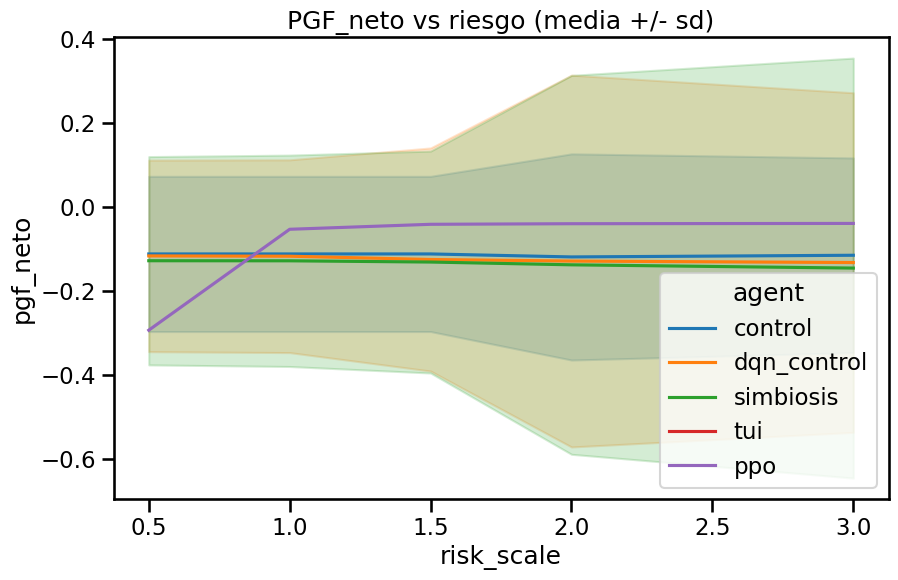

In [53]:
# Lineas PGF_neto vs riesgo
plt.figure()
sns.lineplot(data=df, x="risk_scale", y="pgf_neto", hue="agent", estimator="mean", ci="sd")
plt.title("PGF_neto vs riesgo (media +/- sd)")
pgf_line_path = REPORTS_DIR / "pgf_neto_vs_riesgo.png"
plt.savefig(pgf_line_path, dpi=200, bbox_inches="tight")
pgf_line_path

C:\Users\jrivera\AppData\Local\Temp\ipykernel_21904\3624245198.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="risk_scale", y="tripwires", hue="agent", estimator="mean", ci="sd")


WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/tripwires_vs_riesgo.png')

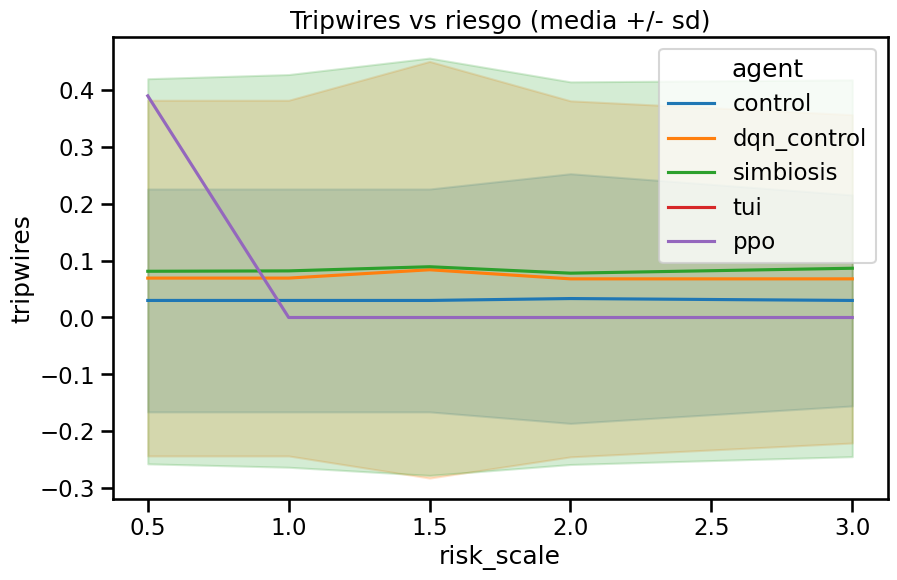

In [54]:
# Lineas tripwires vs riesgo
plt.figure()
sns.lineplot(data=df, x="risk_scale", y="tripwires", hue="agent", estimator="mean", ci="sd")
plt.title("Tripwires vs riesgo (media +/- sd)")
trip_line_path = REPORTS_DIR / "tripwires_vs_riesgo.png"
plt.savefig(trip_line_path, dpi=200, bbox_inches="tight")
trip_line_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/pgf_neto_boxplot.png')

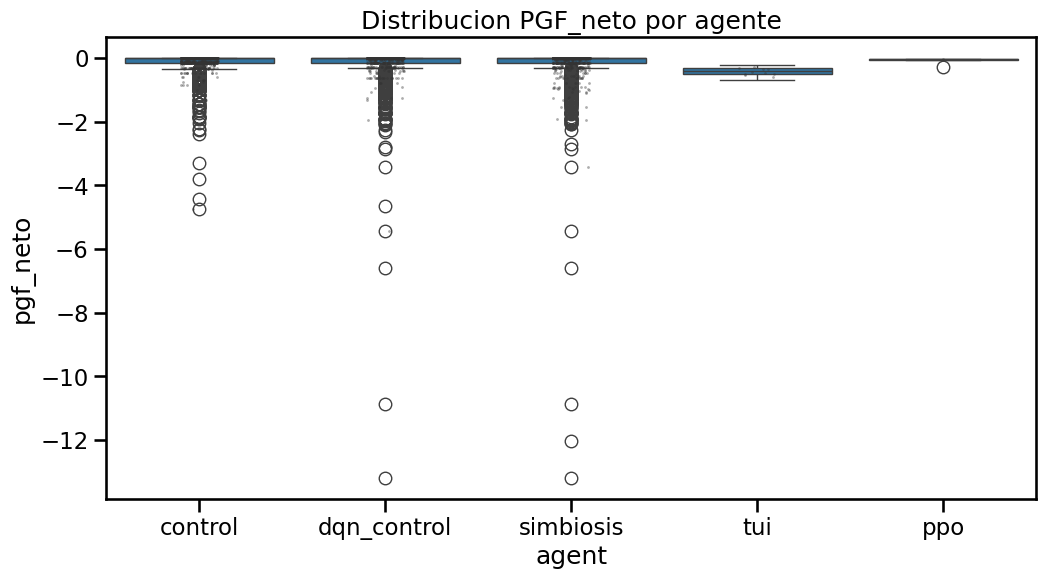

In [6]:
# Boxplots por seed para PGF_neto
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="agent", y="pgf_neto")
sns.stripplot(data=df.sample(min(len(df), 2000)), x="agent", y="pgf_neto", color="0.2", size=2, alpha=0.4)
plt.title("Distribucion PGF_neto por agente")
pgf_box_path = REPORTS_DIR / "pgf_neto_boxplot.png"
plt.savefig(pgf_box_path, dpi=200, bbox_inches="tight")
pgf_box_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/recompensa_vs_tripwires.png')

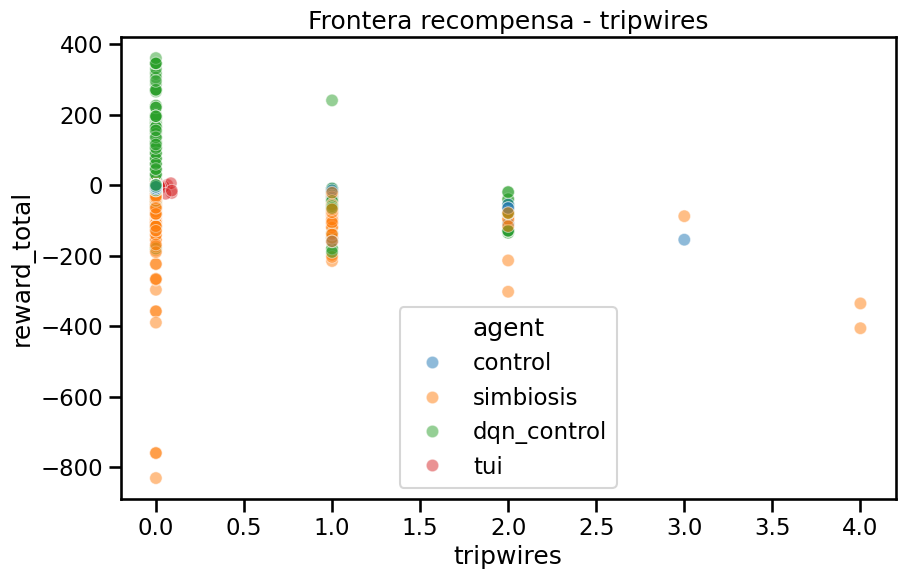

In [7]:
# Scatter recompensa vs tripwires
plt.figure()
sns.scatterplot(data=df.sample(min(len(df), 5000)), x="tripwires", y="reward_total", hue="agent", alpha=0.5)
plt.title("Frontera recompensa - tripwires")
scatter_path = REPORTS_DIR / "recompensa_vs_tripwires.png"
plt.savefig(scatter_path, dpi=200, bbox_inches="tight")
scatter_path

Graficos y tablas guardados en `reports/phase2/`. Ajusta seeds/episodios/PGF en el pipeline antes de re-ejecutar este notebook si cambian los insumos.

## Graficos adicionales

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/pgf_heatmap_risk_agent.png')

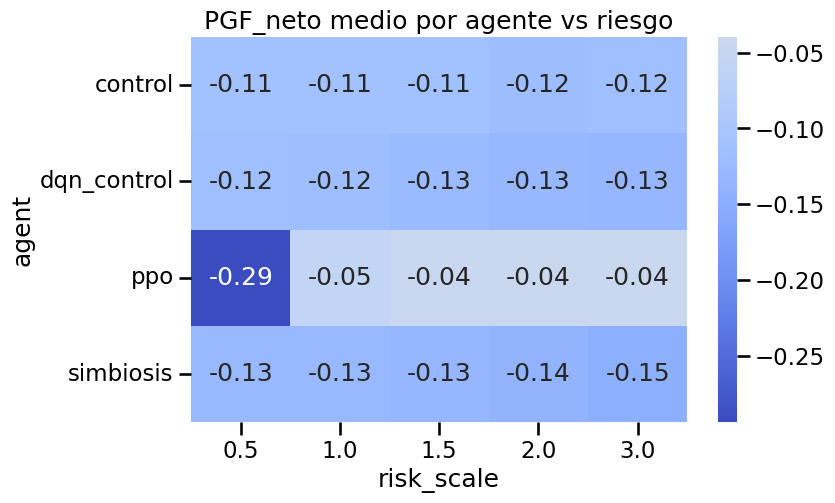

In [8]:
# Heatmap PGF_neto medio por agente y riesgo
plt.figure(figsize=(8, 5))
tmp = df.dropna(subset=["risk_scale"])
pgf_pivot = tmp.pivot_table(values="pgf_neto", index="agent", columns="risk_scale", aggfunc="mean")
sns.heatmap(pgf_pivot, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PGF_neto medio por agente vs riesgo")
pgf_heatmap_path = REPORTS_DIR / "pgf_heatmap_risk_agent.png"
plt.savefig(pgf_heatmap_path, dpi=200, bbox_inches="tight")
pgf_heatmap_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/tripwires_heatmap_risk_agent.png')

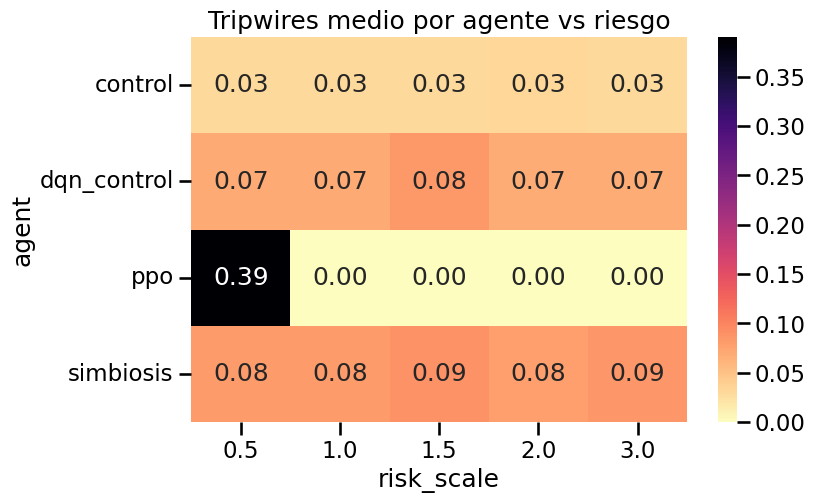

In [9]:
# Heatmap tripwires medio por agente y riesgo
plt.figure(figsize=(8, 5))
trip_pivot = tmp.pivot_table(values="tripwires", index="agent", columns="risk_scale", aggfunc="mean")
sns.heatmap(trip_pivot, annot=True, fmt=".2f", cmap="magma_r")
plt.title("Tripwires medio por agente vs riesgo")
trip_heatmap_path = REPORTS_DIR / "tripwires_heatmap_risk_agent.png"
plt.savefig(trip_heatmap_path, dpi=200, bbox_inches="tight")
trip_heatmap_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/frontier_pgf_tripwires_facet_risk.png')

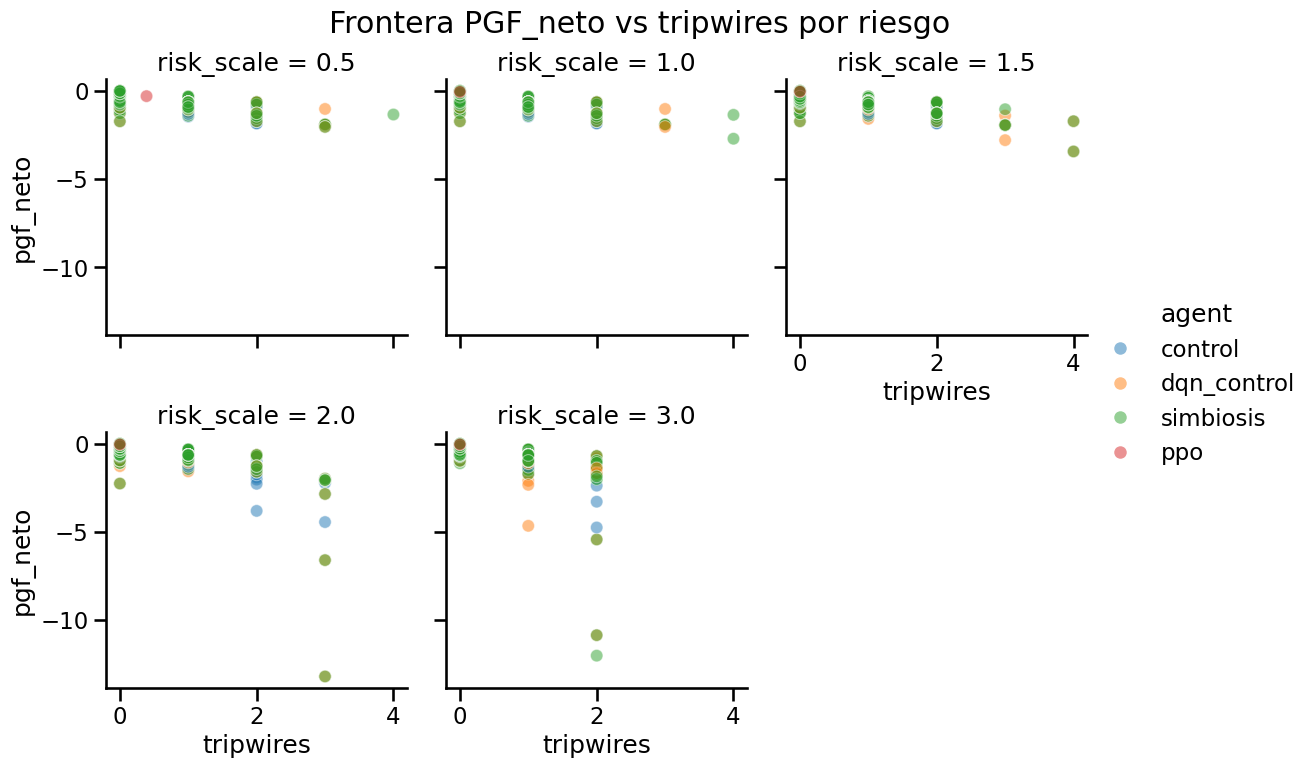

In [10]:
# Frontera PGF_neto vs tripwires faceteada por riesgo
g = sns.relplot(data=tmp, x="tripwires", y="pgf_neto", hue="agent", col="risk_scale", col_wrap=3, height=3.8, alpha=0.5)
g.fig.suptitle("Frontera PGF_neto vs tripwires por riesgo", y=1.02)
frontier_path = REPORTS_DIR / "frontier_pgf_tripwires_facet_risk.png"
g.fig.savefig(frontier_path, dpi=200, bbox_inches="tight")
frontier_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/violin_pgf_tripwires_by_agent.png')

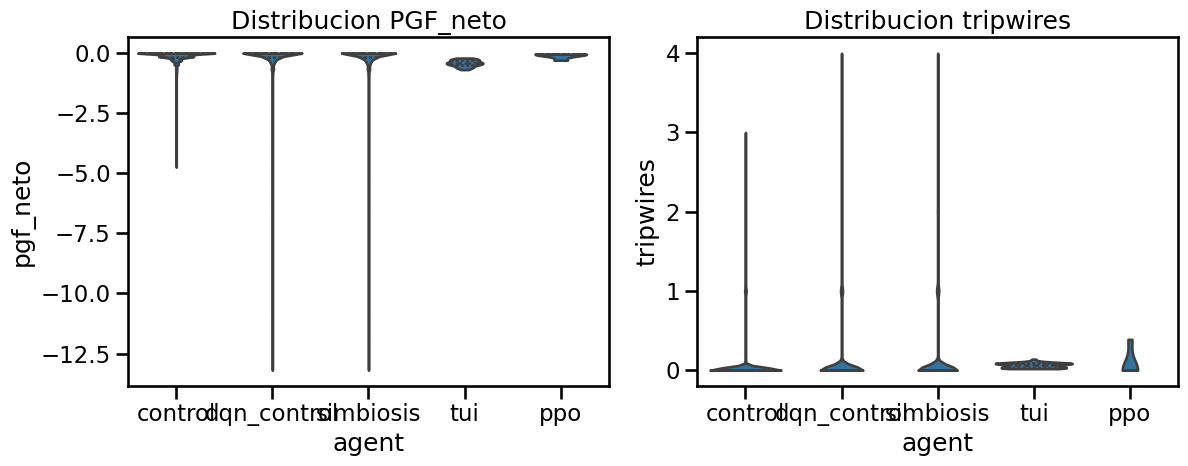

In [11]:
# Violinplots de PGF_neto y tripwires por agente
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=df, x="agent", y="pgf_neto", ax=axes[0], inner="quartile", cut=0)
axes[0].set_title("Distribucion PGF_neto")
sns.violinplot(data=df, x="agent", y="tripwires", ax=axes[1], inner="quartile", cut=0)
axes[1].set_title("Distribucion tripwires")
fig.tight_layout()
violin_path = REPORTS_DIR / "violin_pgf_tripwires_by_agent.png"
fig.savefig(violin_path, dpi=200, bbox_inches="tight")
violin_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/corr_metrics.png')

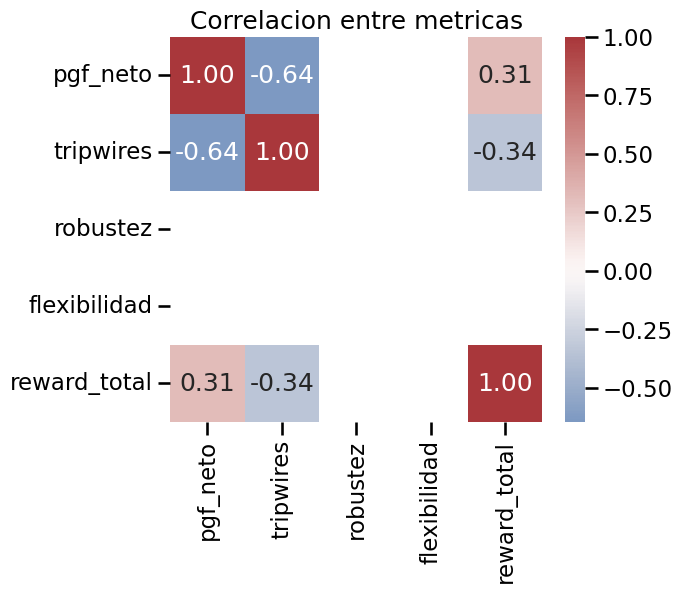

In [12]:
# Correlacion entre metricas
metrics = ["pgf_neto", "tripwires", "robustez", "flexibilidad", "reward_total"]
corr = df[metrics].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlacion entre metricas")
corr_path = REPORTS_DIR / "corr_metrics.png"
plt.savefig(corr_path, dpi=200, bbox_inches="tight")
corr_path

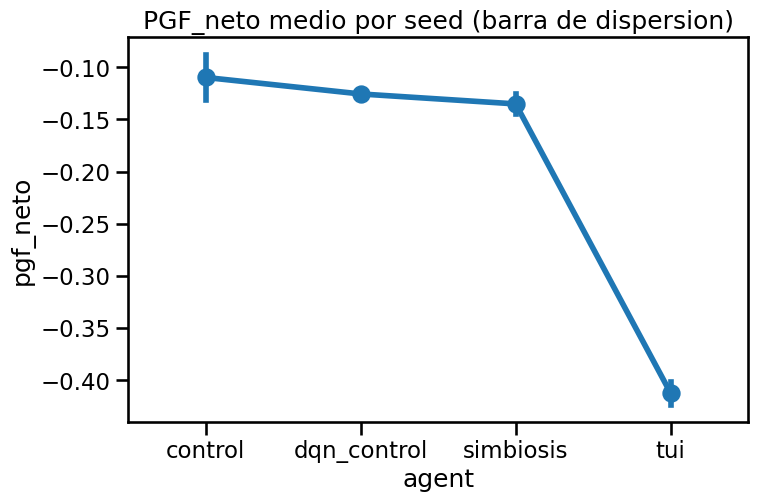

In [13]:
# Estabilidad por seed (PGF_neto)
if "seed" in df.columns:
    seed_stats = df.groupby(["agent", "seed"])['pgf_neto'].mean().reset_index()
    plt.figure(figsize=(8, 5))
    sns.pointplot(data=seed_stats, x="agent", y="pgf_neto", errorbar="sd")
    plt.title("PGF_neto medio por seed (barra de dispersion)")
    seed_stab_path = REPORTS_DIR / "pgf_seed_stability.png"
    plt.savefig(seed_stab_path, dpi=200, bbox_inches="tight")
    seed_stab_path
else:
    print("No hay columna seed, se omite grafico de estabilidad")


In [14]:
# Efecto de hiperparametros (kappa, lambda, mix)
hypers = [c for c in ["kappa", "lambda", "mix"] if c in df.columns]
paths = []
for hyp in hypers:
    if df[hyp].nunique(dropna=True) > 1:
        plt.figure(figsize=(8, 5))
        sns.lineplot(data=df, x=hyp, y="pgf_neto", hue="agent", estimator="mean", ci="sd")
        plt.title(f"PGF_neto vs {hyp}")
        p = REPORTS_DIR / f"pgf_vs_{hyp}.png"
        plt.savefig(p, dpi=200, bbox_inches="tight")
        paths.append(p)
if paths:
    paths
else:
    print("Hiperparametros constantes, sin graficos adicionales")


Hiperparametros constantes, sin graficos adicionales
